In [1]:

from ensemble_error import ensemble_error
import numpy as np
import matplotlib.pyplot as plt

Ensemble error: 0.034


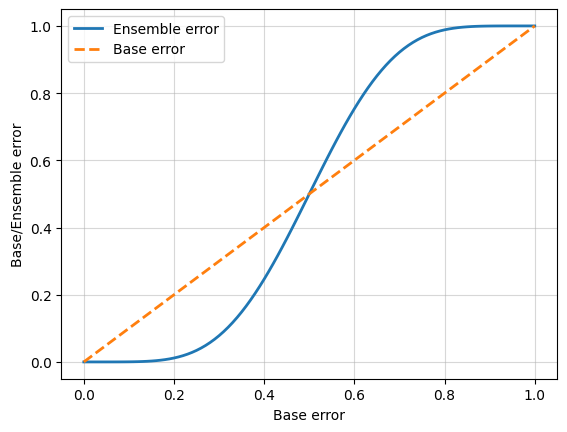

In [2]:
error_range = np.arange(0.0, 1.01, 0.01)
ens_errors = [ensemble_error(n_classifier=11, error=error) 
              for error in error_range]

plt.plot(error_range, ens_errors,
         label='Ensemble error', linewidth=2)
plt.plot(error_range, error_range, linestyle='--', label='Base error',
         linewidth=2)
plt.xlabel('Base error')
plt.ylabel('Base/Ensemble error')
plt.legend(loc='upper left')
plt.grid(alpha=0.5)
plt.show()

In [3]:
np.argmax(np.bincount([0, 0, 1], weights=[0.2, 0.2, 0.6]))

np.int64(1)

In [4]:
from majority_vote import MajorityVoteClassifier

In [5]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
iris = datasets.load_iris()

X, y = iris.data[50:, [1, 2], ], iris.target[50:]

le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.5,
                                                    random_state=1,
                                                    stratify=y)

In [6]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline


clf1 = LogisticRegression(l1_ratio=0, C=0.001, solver='lbfgs', random_state=1)
clf2 = DecisionTreeClassifier(max_depth=1, criterion='entropy', random_state=1)
clf3 = KNeighborsClassifier(n_neighbors=1, p=2, metric='minkowski')

pipe1 = Pipeline(
    [['sc', StandardScaler()],
     ['clf', clf1]]
)


pipe3 = Pipeline([['sc', StandardScaler()],
                  ['clf', clf3]])

clf_labels = ['Logistic regression', 'Decision tree', 'KNN']
print('10-fold cross validation:\n')

for clf, label  in zip([pipe1, clf2, pipe3], clf_labels):
    scores = cross_val_score(estimator=clf, 
                             X=X_train, y=y_train,
                             cv=10,
                             scoring='roc_auc')
    print(f'ROC AUC: {scores.mean():.2f}'
          f' ( {scores.std():.2f}) [{label}]'
          )

10-fold cross validation:

ROC AUC: 0.92 ( 0.15) [Logistic regression]
ROC AUC: 0.87 ( 0.18) [Decision tree]
ROC AUC: 0.85 ( 0.13) [KNN]


In [7]:
mv_clf = MajorityVoteClassifier(classifiers=[pipe1, clf2, pipe3])

clf_labels += ['Majority voting']
all_clf =[pipe1, clf2, pipe3, mv_clf]

for clf, label in zip(all_clf, clf_labels):
    scores = cross_val_score(estimator=clf,
                             X=X_train,
                             y=y_train,
                             cv=10,
                             scoring='roc_auc'
                           )
    
    print(f'ROC AUC: {scores.mean():.2f} '
          f'(+/- {scores.std():.2f}) [{label}]'
          )



ROC AUC: 0.92 (+/- 0.15) [Logistic regression]
ROC AUC: 0.87 (+/- 0.18) [Decision tree]
ROC AUC: 0.85 (+/- 0.13) [KNN]
ROC AUC: 0.98 (+/- 0.05) [Majority voting]


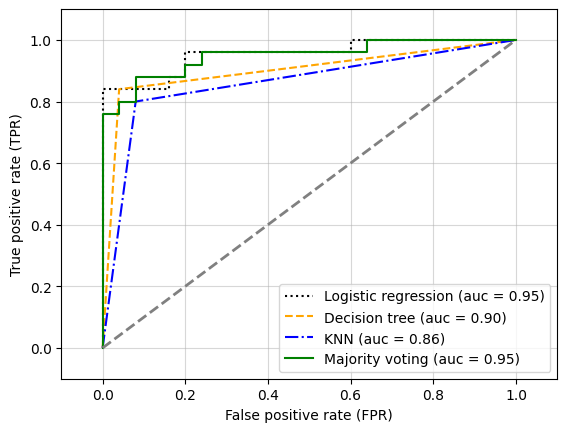

In [8]:
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
colors = ['black', 'orange', 'blue', 'green']
linestyles = [':', '--', '-.', '-']
for clf, label, clr, ls in zip(all_clf, clf_labels, colors, linestyles):
    # assuming the label of the positive class is 1
    y_pred = clf.fit(X_train, y_train).predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_true=y_test, y_score=y_pred)
    roc_auc = auc(x=fpr, y=tpr)
    plt.plot(fpr, tpr, color=clr, linestyle=ls, label=f'{label} (auc = {roc_auc:.2f})')
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=2)
plt.xlim([-0.1, 1.1])
plt.ylim([-0.1, 1.1])
plt.grid(alpha=0.5)
plt.xlabel('False positive rate (FPR)')
plt.ylabel('True positive rate (TPR)')
plt.show()

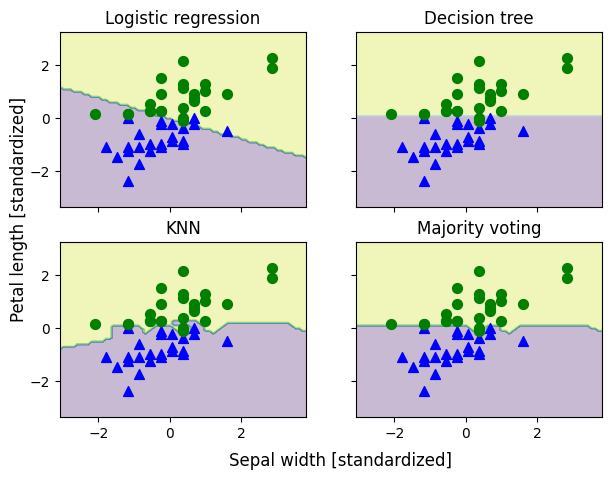

In [9]:
sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)
from itertools import product
x_min = X_train_std[:, 0].min() - 1
x_max = X_train_std[:, 0].max() + 1
y_min = X_train_std[:, 1].min() - 1
y_max = X_train_std[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
f, axarr = plt.subplots(nrows=2, ncols=2, sharex='col', sharey='row', figsize=(7, 5))
for idx, clf, tt in zip(product([0, 1], [0, 1]), all_clf, clf_labels):
    clf.fit(X_train_std, y_train)
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    axarr[idx[0], idx[1]].contourf(xx, yy, Z, alpha=0.3)
    axarr[idx[0], idx[1]].scatter(X_train_std[y_train==0, 0], X_train_std[y_train==0, 1], c='blue', marker='^', s=50)
    axarr[idx[0], idx[1]].scatter(X_train_std[y_train==1, 0], X_train_std[y_train==1, 1], c='green', marker='o', s=50)
    axarr[idx[0], idx[1]].set_title(tt)
plt.text(-3.5, -5., s='Sepal width [standardized]', ha='center', va='center', fontsize=12)
plt.text(-12.5, 4.5, s='Petal length [standardized]', ha='center', va='center', fontsize=12, rotation=90)
plt.show()

In [10]:
import pandas as pd
df_wine = pd.read_csv('https://archive.ics.uci.edu/ml/'
                      'machine-learning-databases/'
                      'wine/wine.data',
                      header=None)
df_wine.columns = ['Class label', 'Alcohol',
                   'Malic acid', 'Ash',
                   'Alcalinity of ash',
                   'Magnesium', 'Total phenols',
                   'Flavanoids', 'Nonflavanoid phenols',
                   'Proanthocyanins',
                   'Color intensity', 'Hue',
                   'OD280/OD315 of diluted wines',
                   'Proline']
# drop 1 class
df_wine = df_wine[df_wine['Class label'] != 1]
y = df_wine['Class label'].values
X = df_wine[['Alcohol',
             'OD280/OD315 of diluted wines']].values

In [11]:
le = LabelEncoder()
y = le.fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)

In [12]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(criterion='entropy', max_depth=None, random_state=1)
bag = BaggingClassifier(
    estimator=tree,
    n_estimators=500,
    max_samples=1.0,
    max_features=1.0,
    bootstrap=True,
    bootstrap_features=False,
    # n_jobs=1,
    random_state=1
)



In [13]:
from sklearn.metrics import accuracy_score
tree = tree.fit(X_train, y_train)
y_train_pred = tree.predict(X_train)
y_test_pred = tree.predict(X_test)
tree_train = accuracy_score(y_train, y_train_pred)
tree_test = accuracy_score(y_test, y_test_pred)

print(f'Decision tree train/test accuracies '
      f'{tree_train:.3f}/{tree_test:.3f}'
      )

Decision tree train/test accuracies 1.000/0.833


In [14]:
bag = bag.fit(X_train, y_train)

y_train_pred = bag.predict(X_train)
y_test_pred = bag.predict(X_test)

bag_train = accuracy_score(y_train, y_train_pred)
bag_test = accuracy_score(y_test, y_test_pred)


print(f'Decision tree train/test accuracies '
      f'{bag_train:.3f}/{bag_test:.3f}'
      )

Decision tree train/test accuracies 1.000/0.917


In [15]:
from helpers.utils import plot_decision_regions

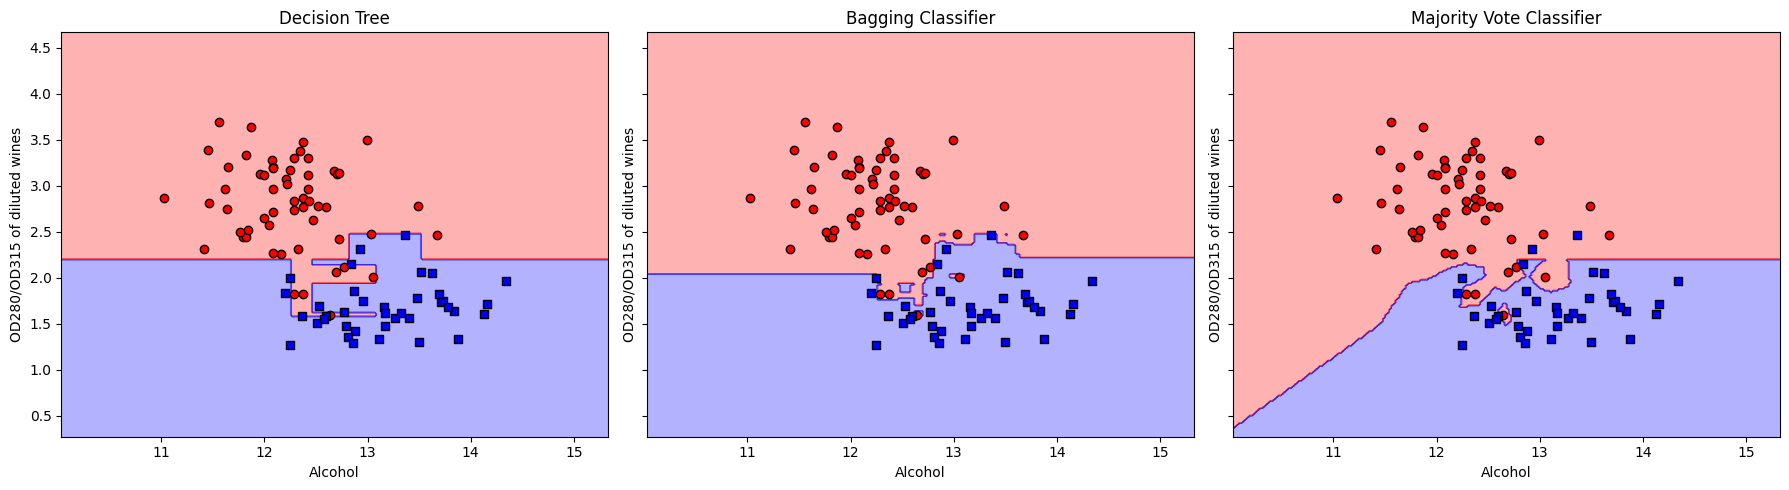

In [18]:
feature_1 = 'Alcohol'
feature_2 = 'OD280/OD315 of diluted wines'

tree.fit(X_train, y_train)
bag.fit(X_train, y_train)
mv_clf.fit(X_train, y_train)

fig, axarr = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

plt.sca(axarr[0])
plot_decision_regions(X_train, y_train, classifier=tree)
axarr[0].set_title('Decision Tree')
axarr[0].set_xlabel(feature_1)
axarr[0].set_ylabel(feature_2)

plt.sca(axarr[1])
plot_decision_regions(X_train, y_train, classifier=bag)
axarr[1].set_title('Bagging Classifier')
axarr[1].set_xlabel(feature_1)
axarr[1].set_ylabel(feature_2)

plt.sca(axarr[2])
plot_decision_regions(X_train, y_train, classifier=mv_clf)
axarr[2].set_title('Majority Vote Classifier')
axarr[2].set_xlabel(feature_1)
axarr[2].set_ylabel(feature_2)

plt.tight_layout()
plt.show()

## AdaBoost Algorithm (Weighted Weak Learners)

For boosting round $j = 1, \dots, m$:

a. Train a weighted weak learner:
$$
C_j = \mathrm{train}(X, y, w)
$$

b. Predict class labels:
$$
\hat{y} = \mathrm{predict}(C_j, X)
$$

c. Compute weighted error rate:
$$
\varepsilon = w \cdot (\hat{y} \neq y)
$$

d. Compute learner coefficient:
$$
\alpha_j = \frac{1}{2}\log\left(\frac{1-\varepsilon}{\varepsilon}\right)
$$

e. Update sample weights:
$$
w := w \times \exp(-\alpha_j \times \hat{y} \times y)
$$

f. Normalize weights to sum to 1:
$$
w := \frac{w}{\sum_i w_i}
$$

Final prediction:
$$
\hat{y} = \left(\sum_{j=1}^{m} \alpha_j\,\mathrm{predict}(C_j, X) > 0\right)
$$

In [19]:
y = np.array([1, 1, 1, -1, -1, -1, 1, 1, 1, -1])
yhat = np.array([1, 1, 1, -1, -1, -1, -1, -1, -1, -1])
correct = (y == yhat)

weights = np.full(10, 0.1)

print(weights)

epsilon = np.mean(~correct)
print(epsilon)

[0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
0.3


In [22]:
alpha_j = 0.5 * np.log((1-epsilon)/epsilon)
print(alpha_j)

0.42364893019360184


In [23]:
update_if_correct = 0.1 * np.exp(-alpha_j * 1 * 1)

print(update_if_correct)

0.06546536707079771


In [24]:
update_if_wrong_1 = 0.1 * np.exp(-alpha_j * 1 * -1)
print(update_if_wrong_1)

0.1527525231651947


In [25]:
weights = np.where(correct == 1, update_if_correct, update_if_wrong_1)

print(weights)
normalized_weights = weights/np.sum(weights)

print(normalized_weights)

[0.06546537 0.06546537 0.06546537 0.06546537 0.06546537 0.06546537
 0.15275252 0.15275252 0.15275252 0.06546537]
[0.07142857 0.07142857 0.07142857 0.07142857 0.07142857 0.07142857
 0.16666667 0.16666667 0.16666667 0.07142857]


In [26]:
from sklearn.ensemble import AdaBoostClassifier
tree = DecisionTreeClassifier(criterion='entropy', random_state=1, max_depth=1)
ada = AdaBoostClassifier(estimator=tree,
                         n_estimators=500,
                         learning_rate=0.1,
                         random_state=1)

tree = tree.fit(X_train, y_train)
y_train_pred = tree.predict(X_train)
y_test_pred = tree.predict(X_test)
tree_train = accuracy_score(y_train, y_train_pred)
tree_test = accuracy_score(y_test, y_test_pred)

print(f'Decision tree train/test accuracies '
      f'{tree_train:.3f}/{tree_test:.3f}'
      )

Decision tree train/test accuracies 0.916/0.875


In [27]:
ada = ada.fit(X_train, y_train)
y_train_pred = ada.predict(X_train)
y_test_pred = ada.predict(X_test)
ada_train = accuracy_score(y_train, y_train_pred)
ada_test = accuracy_score(y_test, y_test_pred)

print(f'Decision tree train/test accuracies '
      f'{ada_train:.3f}/{ada_test:.3f}'
      )

Decision tree train/test accuracies 0.968/0.917


Text(0, 0.5, 'OD280/OD315 of diluted wines')

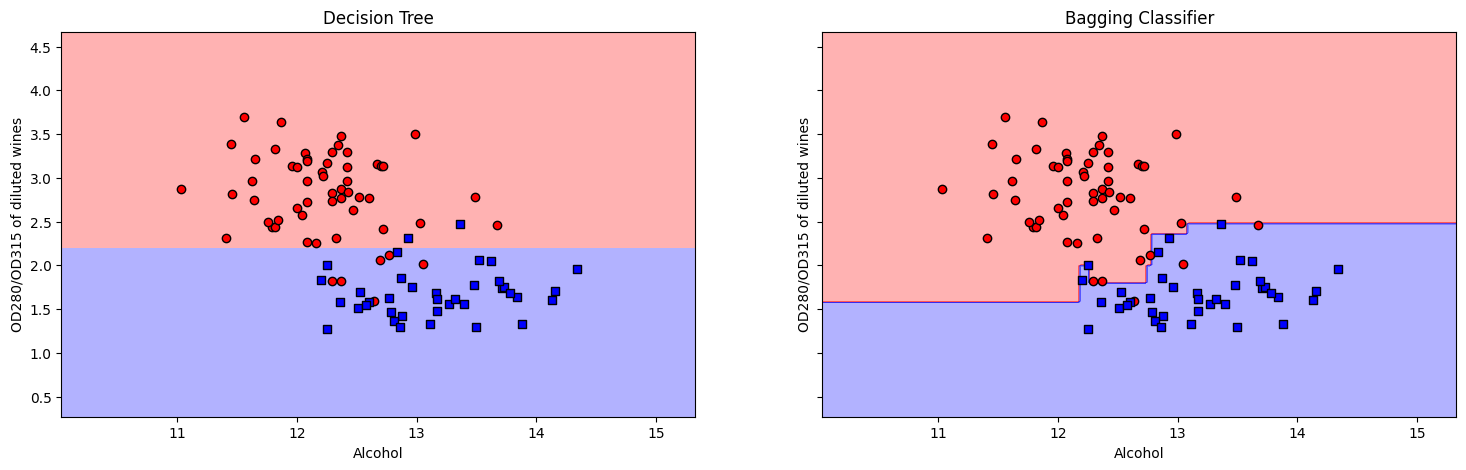

In [29]:
feature_1 = 'Alcohol'
feature_2 = 'OD280/OD315 of diluted wines'


fig, axarr = plt.subplots(1, 2, figsize=(18, 5), sharex=True, sharey=True)

plt.sca(axarr[0])
plot_decision_regions(X_train, y_train, classifier=tree)
axarr[0].set_title('Decision Tree')
axarr[0].set_xlabel(feature_1)
axarr[0].set_ylabel(feature_2)

plt.sca(axarr[1])
plot_decision_regions(X_train, y_train, classifier=ada)
axarr[1].set_title('Bagging Classifier')
axarr[1].set_xlabel(feature_1)
axarr[1].set_ylabel(feature_2)

In [32]:
import xgboost as xgb
model = xgb.XGBClassifier(n_estimators=1000, learning_rate=0.01, 
                          max_depth=4, random_state=1)

In [33]:
gbm = model.fit(X_train, y_train)
y_train_pred = gbm.predict(X_train)
y_test_pred = gbm.predict(X_test)

gbm_train = accuracy_score(y_train, y_train_pred)
gbm_test = accuracy_score(y_test, y_test_pred)

print(f'XGBoost train/test accuracies '
      f'{gbm_train:.3f}/{gbm_test:.3f}')

XGBoost train/test accuracies 0.968/0.917
